# Кластеризация

## Импорты

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score

from src.signal_processing.feature_engineering import calc_psd_at_step_offset, vote_labels
from src.signal_processing.plotting import split_line, markers, plot_eval_hist
from src.submission.kaggle_integration import KaggleSubmitter

## Загрузка данных

In [2]:
signal_df = pd.read_parquet("../data/Run200_Wave_0_1_base_features.parquet")

## Разделение по PCA: Площадь под сигналом vs. Амплитуда
Рассмотрим график Площади под сигналом к Амплитуде.

### График плотности наблюдений: Площадь под сигналом vs. Амплитуда

In [3]:
area_amp = signal_df[['signal_area', 'amplitude']]
area_amp_T = area_amp.T
x = area_amp[['signal_area']].values
y = area_amp['amplitude'].values

In [4]:
kde = gaussian_kde(area_amp_T)
density = kde.evaluate(area_amp_T)

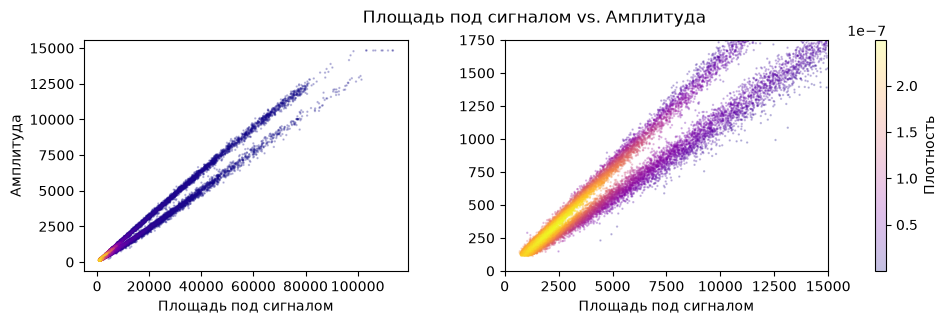

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={'wspace': 0.3})
fig.suptitle("Площадь под сигналом vs. Амплитуда")
sc1 = ax1.scatter(x, y, **markers, c=density, cmap='plasma')
sc2 = ax2.scatter(x, y, **markers, c=density, cmap='plasma')
fig.colorbar(sc1, ax=[ax1, ax2], label='Плотность')
ax1.set_xlabel('Площадь под сигналом')
ax2.set_xlabel('Площадь под сигналом')
ax2.set_xlim(0, 15000)
ax2.set_ylim(0, 1750)
ax1.set_ylabel('Амплитуда')
plt.show()

Видно, что есть возможность сделать разделение через главую компоненту.

### Разделение через PCA

In [6]:
X = signal_df[['signal_area', 'amplitude']]
center = np.mean(X, axis=0)

pca = PCA(n_components=1)
projection = pca.fit_transform(X)
direction = pca.components_[0]
perp_direction = np.array([-direction[1], direction[0]])
perp_projection = X @ np.array([-pca.components_[0, 1], pca.components_[0, 0]])

x0 = 0
y0 = center['amplitude'] + (0 - center['signal_area']) * (direction[1] / direction[0])
x1 = X['signal_area'].max()
y1 = center['amplitude'] + (x1 - center['signal_area']) * (direction[1] / direction[0])

if y0 < 0:
    y0 = 0
    x0 = center['signal_area'] + (0 - center['amplitude']) * (direction[0] / direction[1])
if y1 > X['amplitude'].max():
    y1 = X['amplitude'].max()
    x1 = center['signal_area'] + (y1 - center['amplitude']) * (direction[0] / direction[1])

pca_line_x = [x0, x1]
pca_line_y = [y0, y1]

pca_split_labels = (perp_projection > np.median(perp_projection)).astype(int)
ch_score = calinski_harabasz_score(X, pca_split_labels)

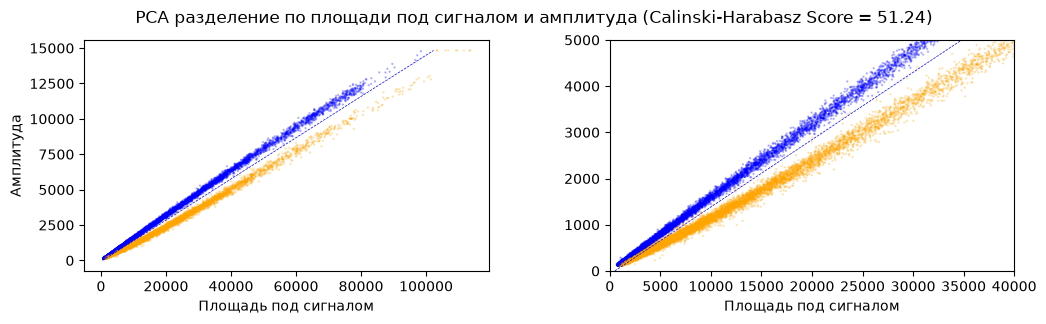

In [7]:
colors = ['orange', 'blue']
label_colors = [colors[l] for l in pca_split_labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={'wspace': 0.3})
fig.suptitle(f'PCA разделение по площади под сигналом и амплитуда (Calinski-Harabasz Score = {ch_score:.2f})')
sc1 = ax1.scatter(x, y, **markers, c=label_colors)
ax1.plot(pca_line_x, pca_line_y, **split_line)
sc2 = ax2.scatter(x, y, **markers, c=[colors[l] for l in pca_split_labels])
ax2.plot(pca_line_x, pca_line_y, **split_line)
ax1.set_xlabel('Площадь под сигналом')
ax2.set_xlabel('Площадь под сигналом')
ax1.set_ylabel('Амплитуда')
ax2.set_xlim(0, 40000)
ax2.set_ylim(0, 5000)
plt.show()

In [8]:
signal_amp_ratio = X['signal_area'] / X['amplitude']

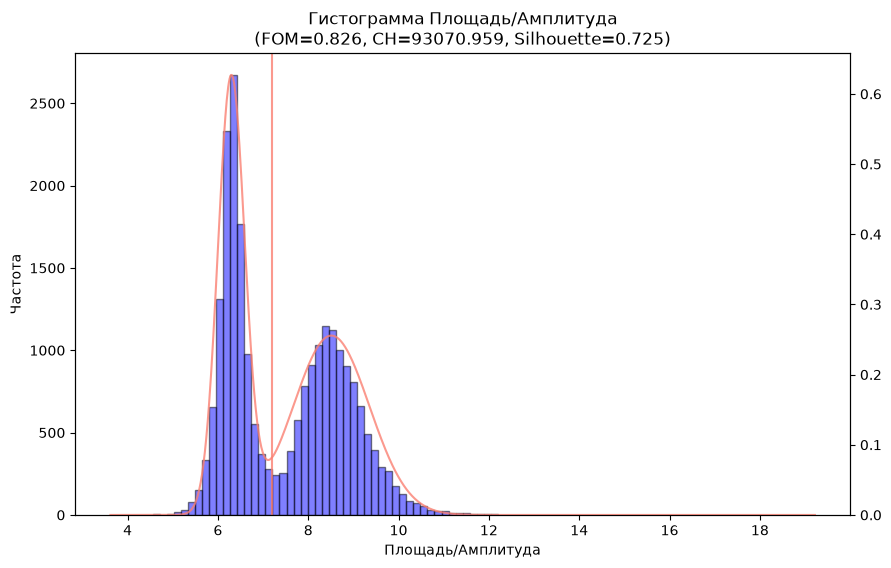

In [9]:
signal_amp_metrics = plot_eval_hist(signal_amp_ratio.values,
                                    title='Гистограмма Площадь/Амплитуда',
                                    x_label='Площадь/Амплитуда')

Стоит отметить, что Calinski-Harabasz Score до преобразования отношения к Площади к Амплитуде был 51.24, а послу стал 93070.959. Т.к. используется бибилотечная функция, по всей видимости, на эту метрику не стоит ориентироваться в дальнейших рассмотрениях качества кластеризации.

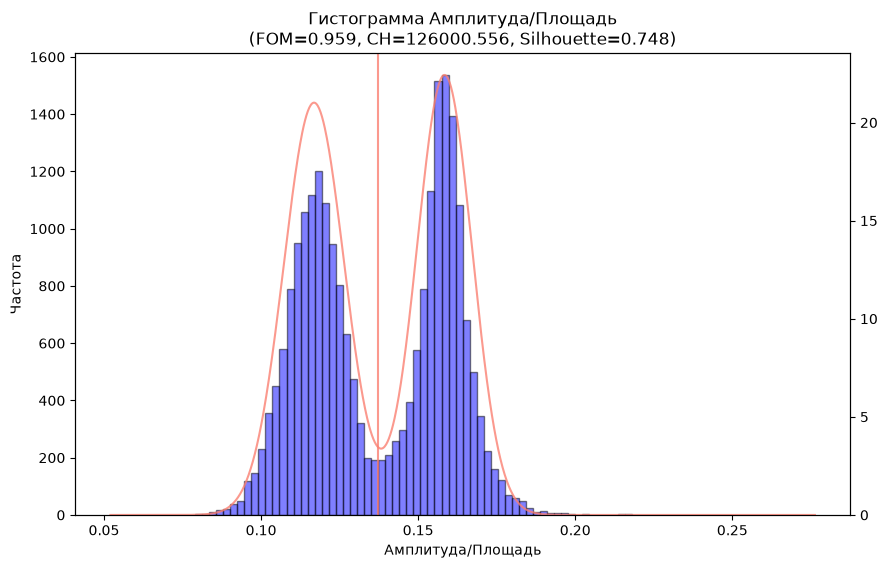

In [10]:
amp_signal_ratio = X['amplitude'] / X['signal_area']
amp_signal_metrics = plot_eval_hist(amp_signal_ratio.values,
                                    title='Гистограмма Амплитуда/Площадь',
                                    x_label='Амплитуда/Площадь')

Отношение Амплитуда/Площадь показывает более высокий FOM, чем отношение Площадь/Амплитуда FOM=0.826 -> FOM=0.959.

## Подбор времени высвечивания: отступ от пика
Самые лучшие значения offset_ticks=0, short_gate=5. 

В такой конфигурации при переборе параметров получены следующие метрики:
- Figure of Merit = 1.147567
- Silhouette Score = 0.787785

In [11]:
psd_df = (signal_df.pipe(lambda _df: calc_psd_at_step_offset(_df, offset_ticks=0, short_gate=5)))

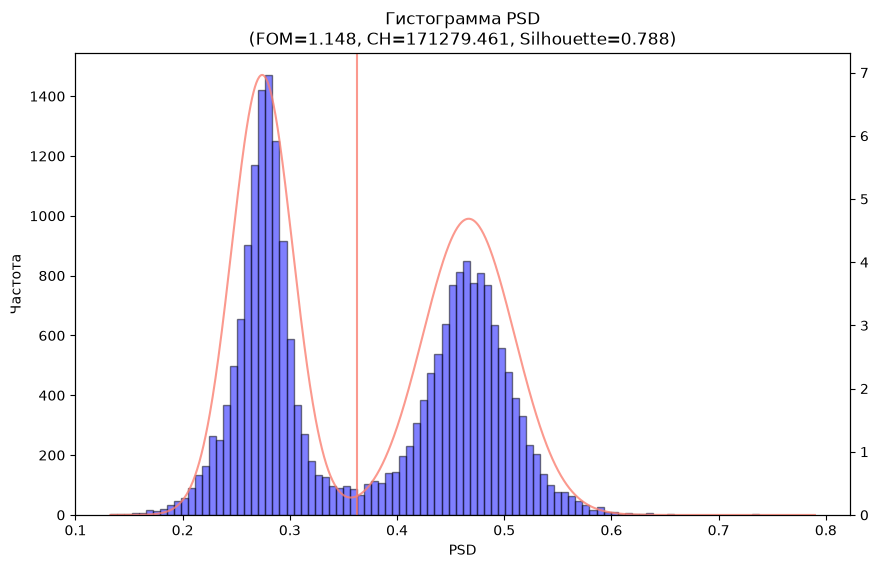

In [12]:
psd_metrics = plot_eval_hist(psd_df['psd'].values, title='Гистограмма PSD', x_label='PSD')

При разделении сигналов по Гистограмме PSD Figure of Merit имеет более высокое значение, чем для метода PCA (FOM=0.959).

## Формирование меток кластеров

In [13]:
pca_split_labels = (signal_amp_ratio.values > signal_amp_metrics['valley']).astype(int)
psd_split_labels = (psd_df['psd'].values > psd_metrics['valley']).astype(int)

In [14]:
resulting_labels = vote_labels(pca_split_labels, psd_split_labels)

In [15]:
label_df = pd.DataFrame({'pca_label': pca_split_labels, 'psd_label': psd_split_labels})
label_df['cluster'] = np.where(label_df['pca_label'] == label_df['psd_label'], label_df['pca_label'], 2)

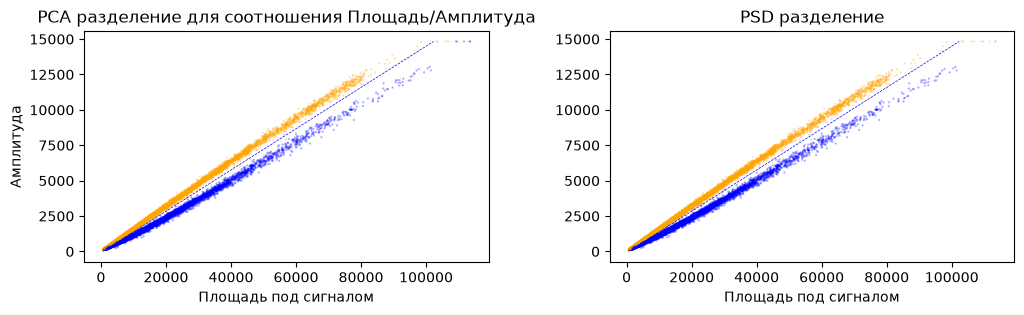

In [16]:
colors = ['orange', 'blue']
pca_label_colors = [colors[l] for l in label_df['pca_label'].to_list()]
psd_label_colors = [colors[l] for l in label_df['psd_label'].to_list()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={'wspace': 0.3})
sc1 = ax1.scatter(x, y, **markers, c=pca_label_colors)
ax1.plot(pca_line_x, pca_line_y, **split_line)
sc2 = ax2.scatter(x, y, **markers, c=psd_label_colors)
ax2.plot(pca_line_x, pca_line_y, **split_line)
ax1.set_title("PCA разделение для соотношения Площадь/Амплитуда")
ax2.set_title("PSD разделение")
ax1.set_xlabel('Площадь под сигналом')
ax2.set_xlabel('Площадь под сигналом')
ax1.set_ylabel('Амплитуда')
plt.show()

## Отправка

In [17]:
submitter = KaggleSubmitter(competition="signal-types-classification")
submitter.auth()

### Без корректировки

In [52]:
label_df.cluster.head()

0    1
1    0
2    0
3    1
4    0
Name: cluster, dtype: int64

In [47]:
label_df.cluster.value_counts().sort_index()

cluster
0    11382
1    11520
2      577
Name: count, dtype: int64

In [57]:
submission_hash_1 = "No corr (C_0=11382, C_1=11520, C_2=577"
label_df[['cluster']].to_csv("../data/submission_1.csv", index_label="index")

In [55]:
submitter.submit_entry(submission_hash=submission_hash_1,
                       submission_path="../data/submission_1.csv")

100%|██████████| 173k/173k [00:01<00:00, 176kB/s] 


In [58]:
submission_result = submitter.get_submission_by_hash(submission_hash_1)

In [59]:
submission_result

{"ref": 54059316, "totalBytes": 176736, "date": "2026-06-25T22:27:51.790Z", "description": "No corr (C_0=11382, C_1=11520, C_2=577", "errorDescription": null, "fileName": "submission_1.csv", "publicScore": "0.01933", "privateScore": null, "status": "COMPLETE", "submittedBy": "alexagarkov", "submittedByRef": "alexagarkov", "teamName": "Alex A.", "url": "/submissions/54059316/54059316.raw"}

### Инвертированные метки

In [7]:
label_df_inverted = label_df[['cluster']].copy(deep=True)
label_df_inverted['cluster'] = np.where(label_df_inverted['cluster'] == 2, 2, 1 - label_df_inverted['cluster'])

In [35]:
label_df_inverted.cluster.value_counts().sort_index()

cluster
0    11520
1    11382
2      577
Name: count, dtype: int64

In [36]:
submission_hash_3 = "No corr (C_0=11520, C_1=11382, C_2=577) attempt 2"
label_df_inverted[['cluster']].to_csv("../data/submission_3.csv", index_label="index")

In [37]:
submitter.submit_entry(submission_hash=submission_hash_3,
                       submission_path="../data/submission_3.csv")

100%|██████████| 173k/173k [00:00<00:00, 194kB/s] 


In [43]:
submission_result = submitter.get_submission_by_hash(submission_hash_3)
submission_result

{"ref": 54059580, "totalBytes": 176736, "date": "2026-06-25T22:47:15.623Z", "description": "No corr (C_0=11520, C_1=11382, C_2=577) attempt 2", "errorDescription": null, "fileName": "submission_3.csv", "publicScore": "0.83176", "privateScore": null, "status": "COMPLETE", "submittedBy": "alexagarkov", "submittedByRef": "alexagarkov", "teamName": "Alex A.", "url": "/submissions/54059580/54059580.raw"}

### С корректировкой сигналов 1929, 19696
Стоит отметить, что оба сигнала до переназначения принадлежали к кластеру 0.

In [39]:
label_df_corrected = label_df.copy(deep=True)
label_df_corrected.iloc[1929] = 2
label_df_corrected.iloc[19696] = 2
label_df_corrected['cluster'] = np.where(label_df_corrected['cluster'] == 2, 2, 1 - label_df_corrected['cluster'])
label_df_corrected.cluster.value_counts().sort_index()

cluster
0    11520
1    11380
2      579
Name: count, dtype: int64

In [40]:
submission_hash_4 = "Signals 1929, 19696 corrected (C_0=11520, C_1=11380, C_2=579)"
label_df_corrected[['cluster']].to_csv("../data/submission_4.csv", index_label="index")

In [41]:
submitter.submit_entry(submission_hash=submission_hash_4,
                       submission_path="../data/submission_4.csv")

100%|██████████| 173k/173k [00:01<00:00, 175kB/s] 


In [44]:
submission_result = submitter.get_submission_by_hash(submission_hash_4)
submission_result

{"ref": 54059619, "totalBytes": 176736, "date": "2026-06-25T22:49:36.547Z", "description": "Signals 1929, 19696 corrected (C_0=11520, C_1=11380, C_2=579)", "errorDescription": null, "fileName": "submission_4.csv", "publicScore": "0.83167", "privateScore": null, "status": "COMPLETE", "submittedBy": "alexagarkov", "submittedByRef": "alexagarkov", "teamName": "Alex A.", "url": "/submissions/54059619/54059619.raw"}

### Только PCA

In [45]:
labels_pca_df = pd.DataFrame({"cluster": pca_split_labels})
labels_pca_df['cluster'].value_counts()

cluster
0    11740
1    11739
Name: count, dtype: int64

In [46]:
submission_hash_5 = "PCA Only"
labels_pca_df[['cluster']].to_csv("../data/submission_5.csv", index_label="index")

In [47]:
submitter.submit_entry(submission_hash=submission_hash_5,
                       submission_path="../data/submission_5.csv")

100%|██████████| 173k/173k [00:00<00:00, 180kB/s]  


In [49]:
submission_result = submitter.get_submission_by_hash(submission_hash_5)
submission_result

{"ref": 54059648, "totalBytes": 176736, "date": "2026-06-25T22:52:02.190Z", "description": "PCA Only", "errorDescription": null, "fileName": "submission_5.csv", "publicScore": "0.83998", "privateScore": null, "status": "COMPLETE", "submittedBy": "alexagarkov", "submittedByRef": "alexagarkov", "teamName": "Alex A.", "url": "/submissions/54059648/54059648.raw"}

### PCA с корректировкой сигналов 1929, 19696

In [51]:
labels_pca_corrected_df = labels_pca_df[['cluster']].copy(deep=True)
labels_pca_corrected_df.iloc[1929] = 2
labels_pca_corrected_df.iloc[19696] = 2
labels_pca_corrected_df['cluster'].value_counts().sort_index()

cluster
0    11740
1    11737
2        2
Name: count, dtype: int64

In [52]:
submission_hash_6 = "PCA Only (1929 and 19696 corrected)"
labels_pca_corrected_df[['cluster']].to_csv("../data/submission_6.csv", index_label="index")

In [53]:
submitter.submit_entry(submission_hash=submission_hash_6,
                       submission_path="../data/submission_6.csv")

100%|██████████| 173k/173k [00:01<00:00, 171kB/s] 


In [54]:
submission_result = submitter.get_submission_by_hash(submission_hash_6)
submission_result

{"ref": 54059713, "totalBytes": 176736, "date": "2026-06-25T22:57:00.053Z", "description": "PCA Only (1929 and 19696 corrected)", "errorDescription": null, "fileName": "submission_6.csv", "publicScore": "0.83989", "privateScore": null, "status": "COMPLETE", "submittedBy": "alexagarkov", "submittedByRef": "alexagarkov", "teamName": "Alex A.", "url": "/submissions/54059713/54059713.raw"}

Корректировка сигналов 1929, 19696 ухудшает скор 0.83998 -> 0.83989. 

### Только PSD

In [19]:
labels_psd_df = pd.DataFrame({"cluster": psd_split_labels})
labels_psd_df['cluster'] = np.where(labels_psd_df['cluster'] == 2, 2, 1 - labels_psd_df['cluster'])
labels_psd_df['cluster'].value_counts()

cluster
1    11796
0    11683
Name: count, dtype: int64

In [20]:
submission_hash_7 = "PSD Only"
labels_psd_df[['cluster']].to_csv("../data/submission_7.csv", index_label="index")

In [21]:
submitter.submit_entry(submission_hash=submission_hash_7,
                       submission_path="../data/submission_7.csv")

100%|██████████| 173k/173k [00:00<00:00, 187kB/s] 


In [22]:
submission_result = submitter.get_submission_by_hash(submission_hash_7)
submission_result

{"ref": 54059865, "totalBytes": 176736, "date": "2026-06-25T23:10:27.713Z", "description": "PSD Only", "errorDescription": null, "fileName": "submission_7.csv", "publicScore": "0.84522", "privateScore": null, "status": "COMPLETE", "submittedBy": "alexagarkov", "submittedByRef": "alexagarkov", "teamName": "Alex A.", "url": "/submissions/54059865/54059865.raw"}

### amp_signal_metrics

In [26]:
amp_signal_pca_labels = (amp_signal_ratio.values > amp_signal_metrics['valley']).astype(int)
amp_signal_pca_df = pd.DataFrame({"cluster": amp_signal_pca_labels})
amp_signal_pca_df['cluster'].value_counts()

cluster
0    11805
1    11674
Name: count, dtype: int64

In [27]:
submission_hash_8 = "Amp/Signal PCA (C_0=11805, C_1=11674)"
amp_signal_pca_df[['cluster']].to_csv("../data/submission_8.csv", index_label="index")

In [28]:
submitter.submit_entry(submission_hash=submission_hash_8,
                       submission_path="../data/submission_8.csv")

100%|██████████| 173k/173k [00:00<00:00, 179kB/s] 


In [29]:
submission_result = submitter.get_submission_by_hash(submission_hash_8)
submission_result

{"ref": 54059922, "totalBytes": 176736, "date": "2026-06-25T23:15:09.403Z", "description": "Amp/Signal PCA (C_0=11805, C_1=11674)", "errorDescription": null, "fileName": "submission_8.csv", "publicScore": "0.84160", "privateScore": null, "status": "COMPLETE", "submittedBy": "alexagarkov", "submittedByRef": "alexagarkov", "teamName": "Alex A.", "url": "/submissions/54059922/54059922.raw"}

### Signal/Amp

In [33]:
signal_amp_pca_labels = (signal_amp_ratio.values <= signal_amp_metrics['valley']).astype(int)
signal_amp_pca_df = pd.DataFrame({"cluster": signal_amp_pca_labels})
signal_amp_pca_df['cluster'].value_counts()

cluster
0    11934
1    11545
Name: count, dtype: int64

In [34]:
submission_hash_9 = "Signal/Amp PCA (C_0=11934, C_1=11545)"
signal_amp_pca_df[['cluster']].to_csv("../data/submission_9.csv", index_label="index")

In [35]:
submitter.submit_entry(submission_hash=submission_hash_9,
                       submission_path="../data/submission_9.csv")

100%|██████████| 173k/173k [00:01<00:00, 167kB/s]  


In [37]:
submission_result = submitter.get_submission_by_hash(submission_hash_9)
submission_result

{"ref": 54060015, "totalBytes": 176736, "date": "2026-06-25T23:20:57.353Z", "description": "Signal/Amp PCA (C_0=11934, C_1=11545)", "errorDescription": null, "fileName": "submission_9.csv", "publicScore": "0.84083", "privateScore": null, "status": "COMPLETE", "submittedBy": "alexagarkov", "submittedByRef": "alexagarkov", "teamName": "Alex A.", "url": "/submissions/54060015/54060015.raw"}

### PSD inverted + PCA Amp/Signal

In [39]:
psd_split_labels = (psd_df['psd'].values <= psd_metrics['valley']).astype(int)
resulting_labels = vote_labels(amp_signal_pca_labels, psd_split_labels)
label_psd_pca_df = pd.DataFrame({"cluster": resulting_labels})
label_psd_pca_df['cluster'].value_counts()

cluster
0    11467
1    11458
2      554
Name: count, dtype: int64

In [40]:
submission_hash_10 = "PSD + Amp/Signal PCA (C_0=11467, C_1=11458, C_2=554)"
label_psd_pca_df[['cluster']].to_csv("../data/submission_10.csv", index_label="index")

In [41]:
submitter.submit_entry(submission_hash=submission_hash_10,
                       submission_path="../data/submission_10.csv")

100%|██████████| 173k/173k [00:00<00:00, 180kB/s] 


In [42]:
submission_result = submitter.get_submission_by_hash(submission_hash_10)
submission_result

{"ref": 54060087, "totalBytes": 176736, "date": "2026-06-25T23:26:33.657Z", "description": "PSD + Amp/Signal PCA (C_0=11467, C_1=11458, C_2=554)", "errorDescription": null, "fileName": "submission_10.csv", "publicScore": "0.83257", "privateScore": null, "status": "COMPLETE", "submittedBy": "alexagarkov", "submittedByRef": "alexagarkov", "teamName": "Alex A.", "url": "/submissions/54060087/54060087.raw"}

### Перепроверка лучшей отправки

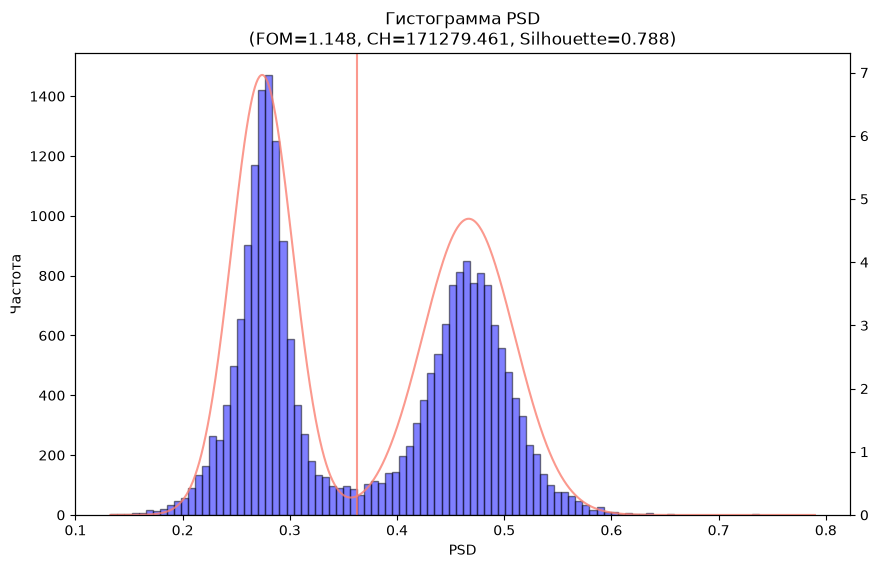

In [18]:
best_submission_df = (signal_df.pipe(lambda _df: calc_psd_at_step_offset(_df, offset_ticks=0, short_gate=5)))
best_submission_metrics = plot_eval_hist(best_submission_df['psd'].values,
                                         title='Гистограмма PSD',
                                         x_label='PSD')

In [19]:
best_labels = (best_submission_df['psd'].values <= best_submission_metrics['valley']).astype(int)
best_submission_cluster_df = pd.DataFrame({"cluster": best_labels})
best_submission_cluster_df['cluster'].value_counts()

cluster
1    11796
0    11683
Name: count, dtype: int64

In [20]:
submission_hash_11 = "PSD (C_0=11683, C_1=11796)"
best_submission_cluster_df[['cluster']].to_csv("../data/submission_11.csv", index_label="index")

In [21]:
submitter.submit_entry(submission_hash=submission_hash_11,
                       submission_path="../data/submission_11.csv")

100%|██████████| 173k/173k [00:00<00:00, 190kB/s] 


In [22]:
submission_result = submitter.get_submission_by_hash(submission_hash_11)
submission_result

{"ref": 54060152, "totalBytes": 176736, "date": "2026-06-25T23:32:58.837Z", "description": "PSD (C_0=11683, C_1=11796)", "errorDescription": null, "fileName": "submission_11.csv", "publicScore": "0.84522", "privateScore": null, "status": "COMPLETE", "submittedBy": "alexagarkov", "submittedByRef": "alexagarkov", "teamName": "Alex A.", "url": "/submissions/54060152/54060152.raw"}